In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
test_metrics = json.load(open('../model/model_output/test_metrics.json', 'r'))

# classification_report
filtered = {
    cls: stats
    for cls, stats in test_metrics['classification_report'].items()
    if isinstance(stats, dict)
}
test_classes = (
    pd.DataFrame.from_dict(filtered, orient='index')
      .reset_index()
      .rename(columns={'index': 'class'})
)

# numeric_metrics/overall metrics
test_overall = (
    pd.DataFrame.from_dict(
        test_metrics['numeric_metrics'],
        orient='index',
        columns=['value']
    )
    .reset_index()
    .rename(columns={'index': 'metric'})
)

In [23]:
test_classes = test_classes[~test_classes["class"].isin(["weighted avg", "macro avg"])]
test_classes

,class,precision,recall,f1-score,support
0,Bradykinin-related peptide family,0.333333,1.000000,0.500000,2.0
1,CRISP family,0.333333,1.000000,0.500000,3.0
2,Cationic peptide family,0.350000,0.875000,0.500000,8.0
3,Conotoxin family,0.658228,0.920354,0.767528,113.0
4,Disintegrin family,0.400000,0.666667,0.500000,3.0
5,FARP (FMRFamide related peptide) family,0.040000,0.500000,0.074074,2.0
6,Flavin monoamine oxidase family,1.000000,1.000000,1.000000,2.0
7,Formicidae venom family,0.235294,0.800000,0.363636,5.0
8,Insulin family,0.250000,1.000000,0.400000,2.0
9,Limacoditoxin family,0.400000,1.000000,0.571429,2.0


In [24]:
test_overall

,metric,value
0,Test_Accuracy,0.930385
1,Test_MCC,0.628515
2,Test_Avg_Loss,0.249296
3,Test_Micro_MCC,0.927984


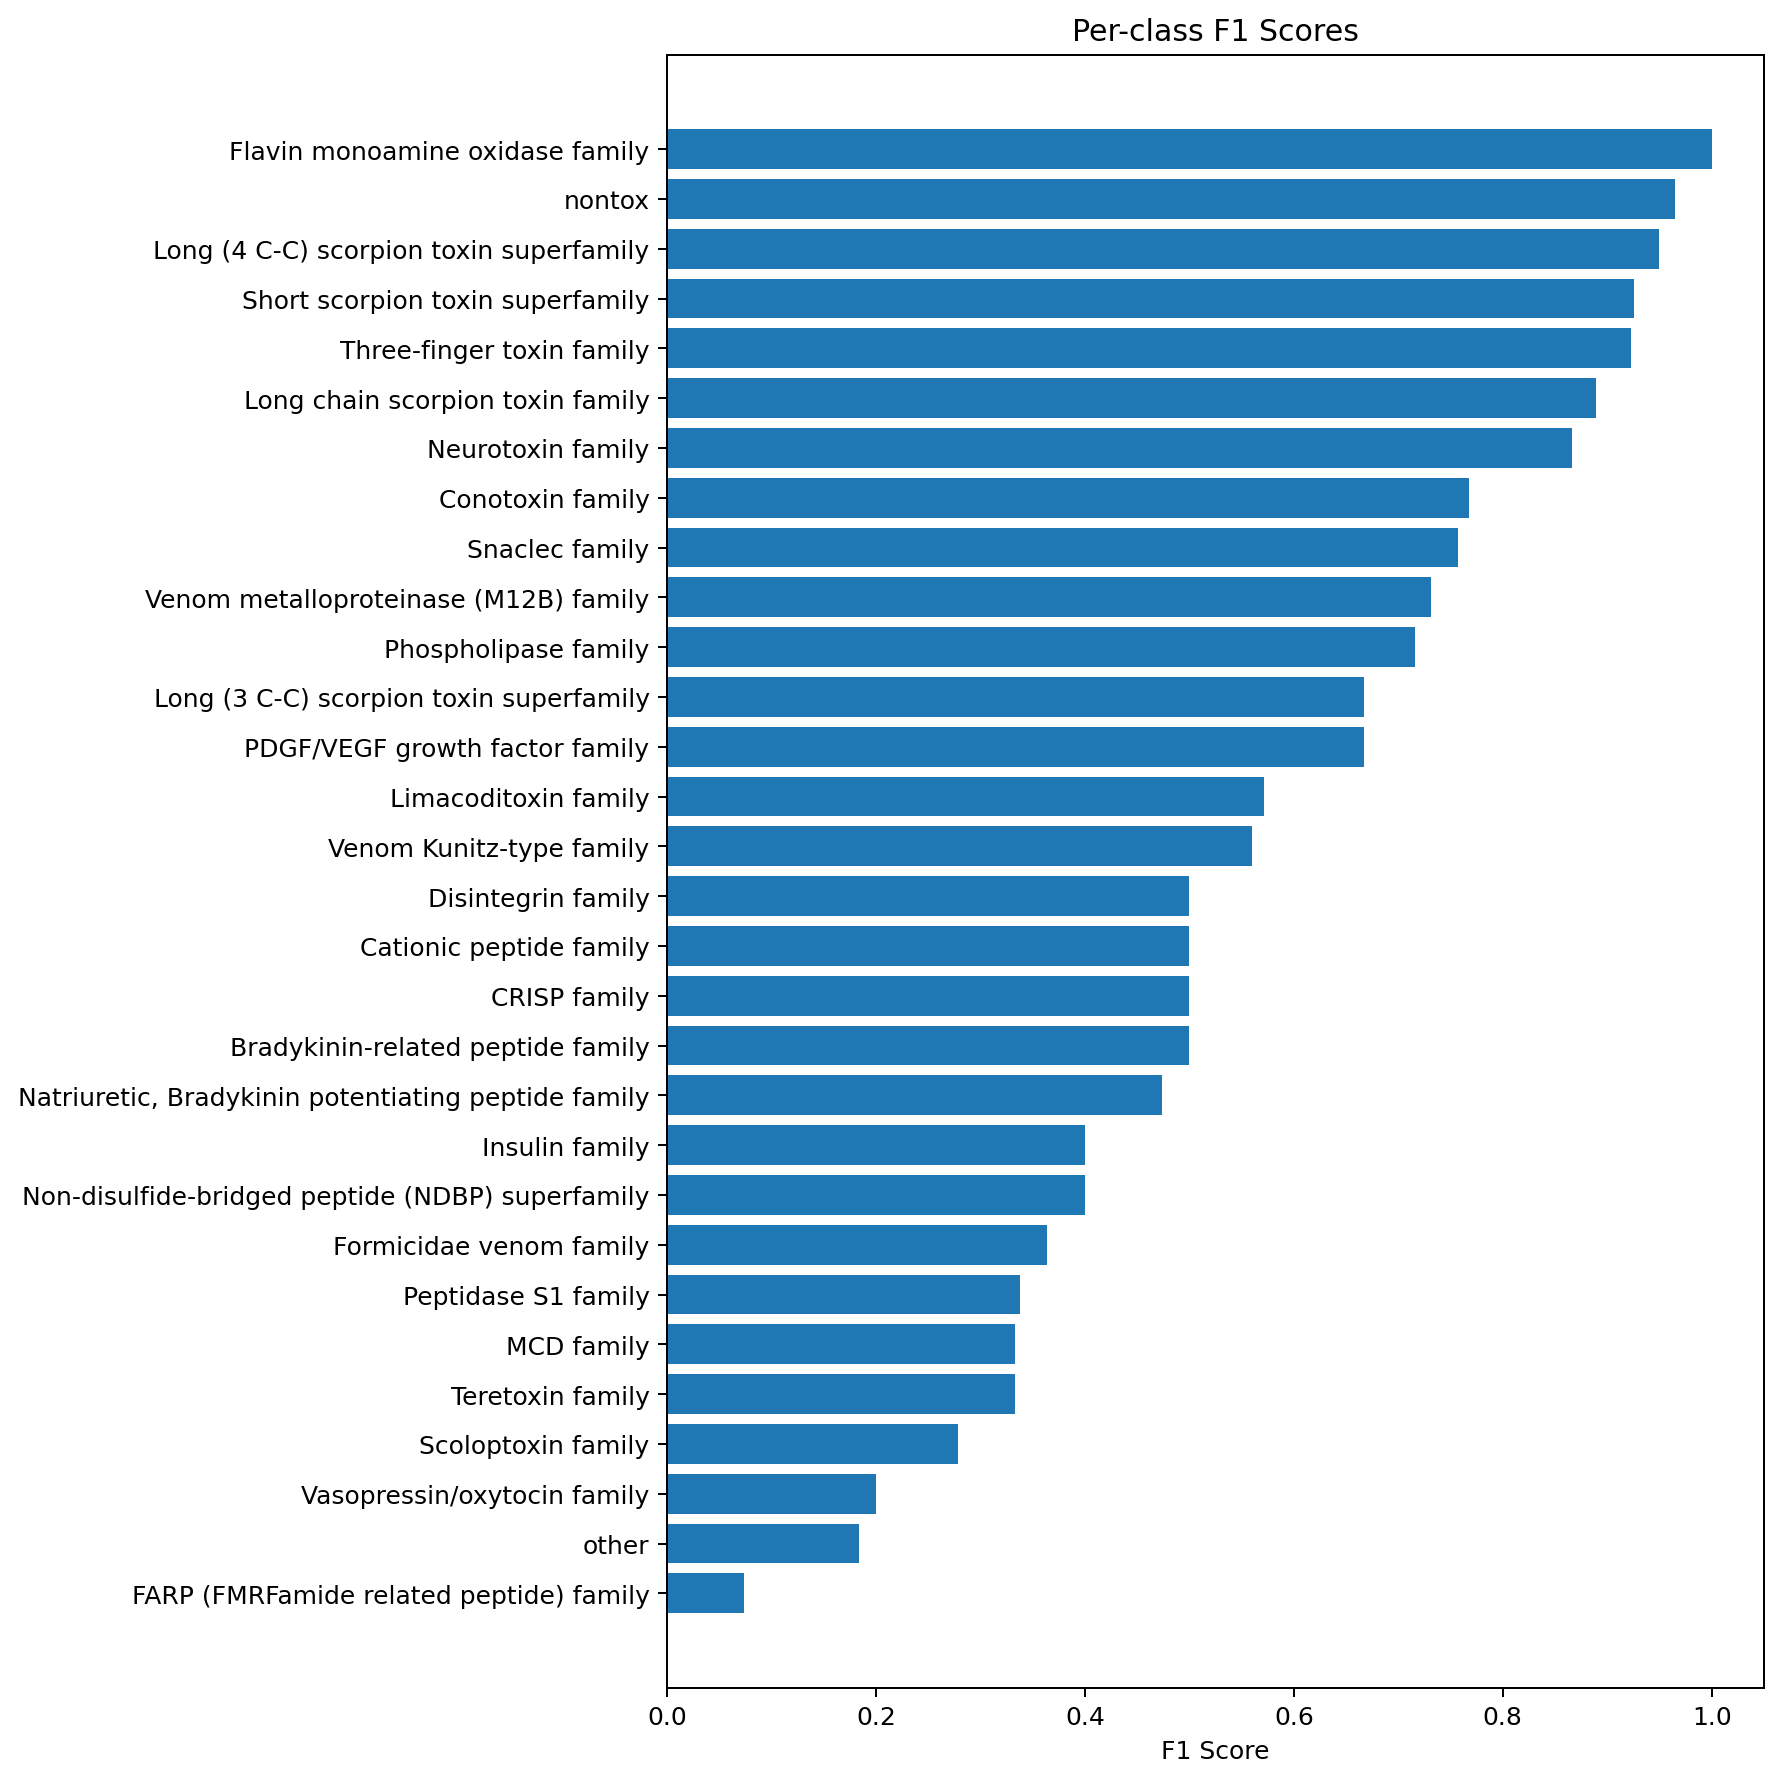

In [25]:
# 1) Per-class F1-score bar chart
df = test_classes.set_index('class').sort_values('f1-score')
plt.figure(figsize=(10,10), dpi=180)
plt.barh(df.index, df['f1-score'])
plt.xlabel('F1 Score')
plt.title('Per-class F1 Scores')
plt.tight_layout()
plt.show()



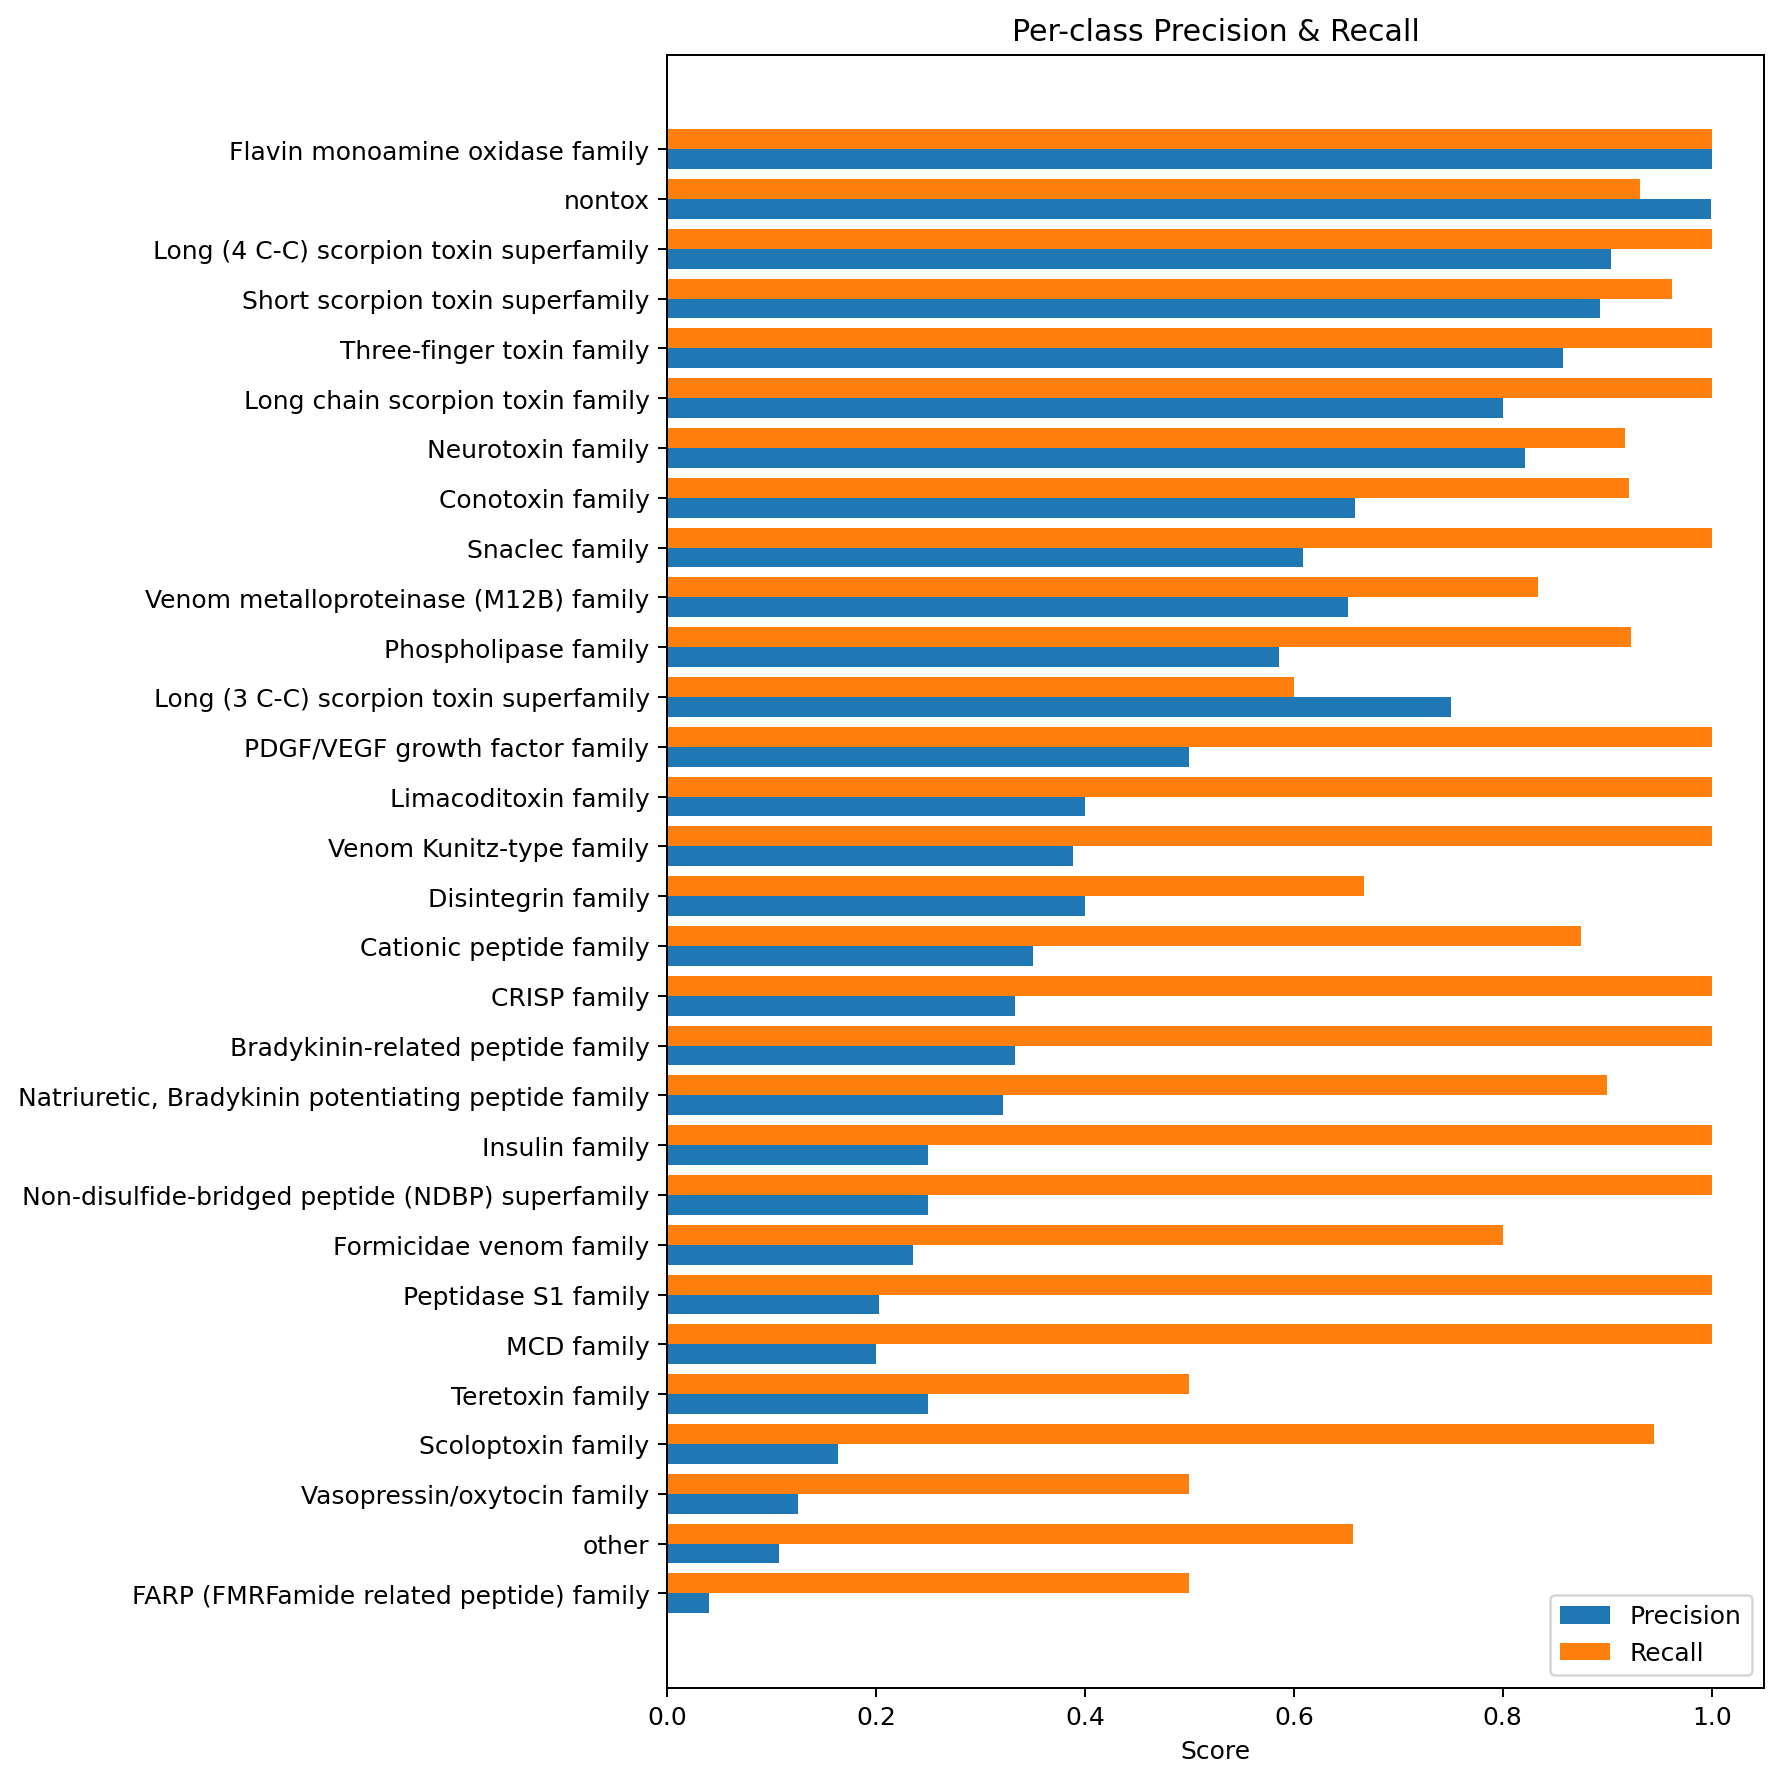

In [26]:
# 2) Per-class precision & recall grouped bars
plt.figure(figsize=(10,10), dpi=180)
x = range(len(df))
width = 0.4
plt.barh([i - width/2 for i in x], df['precision'], height=width, label='Precision')
plt.barh([i + width/2 for i in x], df['recall'],    height=width, label='Recall')
plt.yticks(x, df.index)
plt.xlabel('Score')
plt.legend(loc='lower right')
plt.title('Per-class Precision & Recall')
plt.tight_layout()
plt.show()

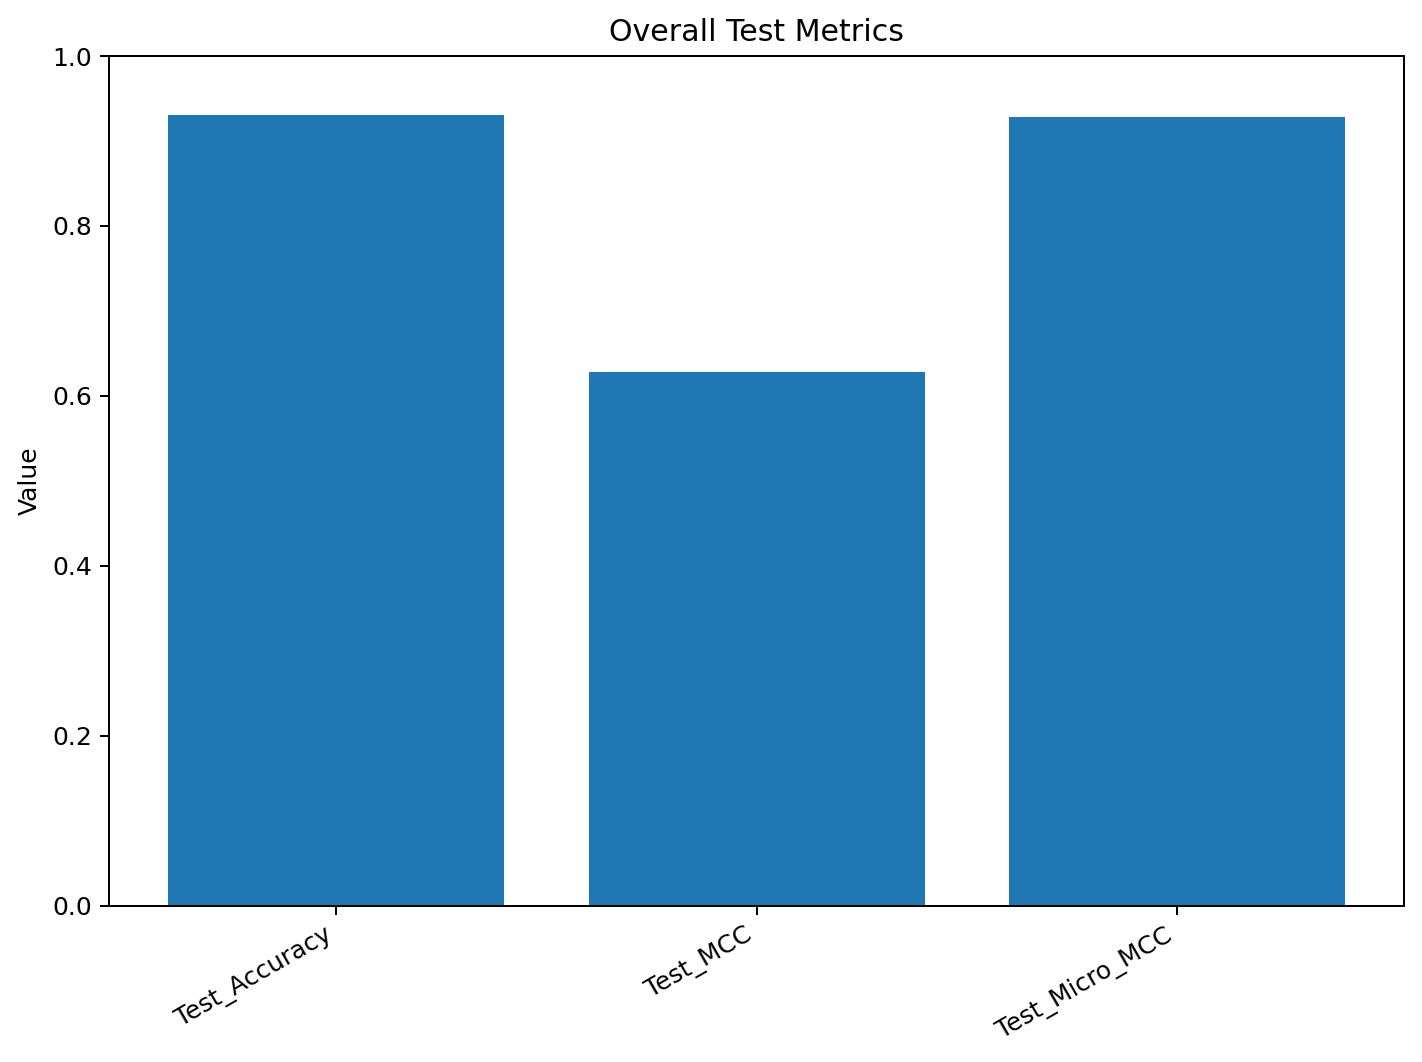

In [27]:
# 3) Overall metrics as a simple bar chart
test_overall = test_overall[~test_overall["metric"].isin(["Test_Avg_Loss"])]

ov = test_overall.set_index('metric')
plt.figure(figsize=(8,6), dpi=180)
plt.bar(ov.index, ov['value'])
plt.ylim(0,1)
plt.ylabel('Value')
plt.title('Overall Test Metrics')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()